In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pickle
import os
import pandas as pd
import networkx as nx
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as scp
from scipy.stats import ranksums, wilcoxon
import sklearn as sk
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.multitest import multipletests

In [2]:
import pandas as pd
from patsy import dmatrices
import statsmodels.api as sm 
import rdata as pyr

In [3]:
immpath1="/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/"

In [4]:
hippiedata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/hippie/"
congenelistdata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/genelist/contextecmcm/"
genelistdata="/home/ajayasha/scratch/Arvind_umd/ECM_proj/genelist/"
UCSCtoilpath="/home/ajayasha/scratch/Arvind_umd/UCSC-TOIL/"
ECMprojpath="/home/ajayasha/scratch/Arvind_umd/ECM_proj/"
RCDprojpath="/home/ajayasha/scratch/Arvind_umd/RCD/"
GDCPANCANpath="/home/ajayasha/scratch/Arvind_umd/GDC-PANCAN/"
depmappath="/home/ajayasha/scratch/Arvind_umd/depmap/"
datapath="/home/ajayasha/scratch/Arvind_umd/"
figpath=ECMprojpath+"Figures/"

In [5]:
import json

In [6]:
for f1 in os.listdir(immpath1):
    for f2 in os.listdir(immpath1+f1):
        if f2.endswith(".Rdata"):
            print(f1+"/"+f2)

Snyder et al/Snyder_data.Rdata
Snyder et al/Snyder_2017.Rdata
Kim et al/Kim_2018.Rdata
Miao et al/Miao_data.Rdata
Miao et al/Miao_2018.Rdata
Braun et al/Braun_2020.Rdata
Braun et al/Braun_data.Rdata
Nathanson et al/Nathanson_PRE_data.Rdata
Nathanson et al/Nathanson_2017.Rdata
Nathanson et al/Nathanson_PRE_2017.Rdata
Nathanson et al/Nathanson_data.Rdata
VanAllen et al/VanAllen_2015.Rdata
Mariathasan et al/Mariathasan_data.Rdata
Mariathasan et al/Mariathasan_2018.Rdata
Jeong Yeon Kim et al/J_Y_Kim_data.Rdata
Liu et al/Liu_EXPOSURE_2019.Rdata
Liu et al/Liu_EXPOSURE_data.Rdata
Liu et al/Liu_2019.Rdata
Liu et al/Liu_data.Rdata
Liu et al/Liu_NAIVE_2019.Rdata
Liu et al/Liu_NAIVE_data.Rdata
Jung et al/Jung_data.Rdata
Jung et al/Jung_2019.Rdata
Motzer et al/Motzer_2020.Rdata
Motzer et al/Motzer_data.Rdata
Riaz et al/Riaz_NAIVE_data.Rdata
Riaz et al/Riaz_EXPOSURE_2017.Rdata
Riaz et al/Riaz_PRE_2017.Rdata
Riaz et al/Riaz_ON_data.Rdata
Riaz et al/Riaz_NAIVE_2017.Rdata
Riaz et al/Riaz_ON_2017.Rdata

In [7]:
os.listdir(immpath1+"Kim et al/")

['Kim_data.RData:Zone.Identifier',
 'Kim_2018.Rdata:Zone.Identifier',
 'ICB.Kim2018_Pembrolizumab_Gastric.self_subtract:Zone.Identifier',
 'ICB.Kim2018_Pembrolizumab_Gastric.clinical:Zone.Identifier',
 'Kim_data.RData',
 'ICB.Kim2018_Pembrolizumab_Gastric.clinical',
 'Kim_2018.Rdata',
 'ICB.Kim2018_Pembrolizumab_Gastric.self_subtract']

In [8]:
icbpathlist=[]
for f1 in os.listdir(immpath1):
    for f2 in os.listdir(immpath1+f1):
        if f2.endswith(".Rdata"):
            result = pyr.parser.parse_file(immpath1+f1+"/"+f2)
            rda=pyr.conversion.convert(result)
            for k in rda.keys():
                if "Clinical" in rda[k].keys() and "TPM" in rda[k].keys():
                    icbpathlist.append(immpath1+f1+"/"+f2)

/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl". The constructor for class "data.frame" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl". The constructor for class 

In [9]:
icbpathlist

['/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Snyder et al/Snyder_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Snyder et al/Snyder_2017.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Kim et al/Kim_2018.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Miao et al/Miao_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Miao et al/Miao_2018.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Braun et al/Braun_2020.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Braun et al/Braun_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Nathanson et al/Nathanson_PRE_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Nathanson et al/Nathanson_2017.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Nathanson et al/Nathanson_PRE_2017.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Nathanson et al/Nathanson_data.Rdata',
 '/home/ajayasha/scratch/Arvi

In [10]:
icbremlist=['/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Braun et al/Braun_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Snyder et al/Snyder_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Miao et al/Miao_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Nathanson et al/Nathanson_PRE_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Nathanson et al/Nathanson_2017.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Nathanson et al/Nathanson_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Mariathasan et al/Mariathasan_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Liu et al/Liu_EXPOSURE_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Liu et al/Liu_NAIVE_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Jung et al/Jung_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Motzer et al/Motzer_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Riaz et al/Riaz_ON_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Riaz et al/Riaz_NAIVE_2017.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Riaz et al/Riaz_ON_2017.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Riaz et al/Riaz_EXPOSURE_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Riaz et al/Riaz_2017.Rdata',
            '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Riaz et al/Riaz_NAIVE_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Riaz et al/Riaz_EXPOSURE_2017.Rdata',
        '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Gide et al/Gide_ON_2019.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Gide et al/Gide_MONO_2019.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Gide et al/Gide_MONO_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Gide et al/Gide_PRE_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Gide et al/Gide_ON_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Gide et al/Gide_COMBINE_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Gide et al/Gide_COMBINE_2019.Rdata',
            '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Gide et al/Gide_2019.Rdata',
            '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Lee et al/Lee_PRE_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Lee et al/Lee_ON_data.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Lee et al/Lee_ON_2020.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Lee et al/Lee_2020.Rdata',
            '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Du et al/MGH_ON_2021.Rdata',
            '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Hugo et al/Hugo_2016.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Hugo et al/Hugo_PRE_data.Rdata',
           '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Liu et al/Liu_2019.Rdata',
 '/home/ajayasha/scratch/Arvind_umd/ECM_proj/ICB_data/Liu et al/Liu_data.Rdata',]

In [11]:
icbpathlistrev=[pl for pl in icbpathlist if pl not in icbremlist]
len(icbpathlistrev)

16

In [14]:
tpmdf={}
clindf={}
sampdf={}
for fp in icbpathlistrev:
    result = pyr.parser.parse_file(fp)
    rda=pyr.conversion.convert(result)
    for k in rda.keys():
        print(k)
        tpmdf[k]=pd.DataFrame(index=rda[k]['TPM']['dim_0'],columns=rda[k]['TPM']['dim_1'],data=rda[k]['TPM'].values)
        clindf[k]=rda[k]['Samples']
        sampdf[k]=rda[k]['Samples']

/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl". The constructor for class "data.frame" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl". The constructor for class 

Snyder_data
Kim_data


/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl". The constructor for class "data.frame" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl". The constructor for class 

Miao_data


/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl". The constructor for class "data.frame" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl". The constructor for class 

...

Liu_NAIVE_data


/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "collector_double". The constructor for class "collector" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "collector". The underlying R object is returned instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "collector_character". The constructor for class "collector" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "collect

Jung_data


/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl". The constructor for class "data.frame" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl_df". The constructor for class "tbl" will be used instead.
  warnings.warn(
/scratch/zt1/project/johnson-lab/user/ajayasha/Arvind_umd/.cancer-ecm/lib/python3.8/site-packages/rdata/conversion/_conversion.py:843: UserWarning: Missing constructor for R class "tbl". The constructor for class 

Motzer_data
Riaz_PRE_data
Gide_PRE_data
Lee_PRE_data
MGH_PRE_data
Hugo_PRE_data


In [15]:
import gseapy as gp

In [16]:
all_hgnc=pd.read_csv(genelistdata+"all_hgnc_biomart.txt",sep='\t',index_col=8, dtype={'Approved symbol':  str, 'NCBI gene ID': str})
ens2sym=all_hgnc[all_hgnc.index.notnull()]['Approved symbol'].to_dict()

In [17]:
moddict={}
for line in open(genelistdata+'supmod_ecmcmmed_rev.tsv','r'):
    line=line.strip()
    cols=line.split("\t")
    moddict[cols[0]]=[ens2sym[x] for x in cols[1:] if x in ens2sym.keys()]

In [18]:
randmoddict={}
for line in open(genelistdata+'ecmcmmed_module_random.tsv','r'):
    line=line.strip()
    cols=line.split("\t")
    randmoddict[cols[0]]=[ens2sym[x] for x in cols[1:] if x in ens2sym.keys()]

In [19]:
def compare_ssgsea_scores(ssgsea_df, groups_df):
    """
    Performs a Wilcoxon rank-sum test to compare ssGSEA scores for each group against the rest.

    Args:
        ssgsea_df (pd.DataFrame): DataFrame with gene sets as rows and samples as columns,
                                  containing ssGSEA enrichment scores.
        groups_df (pd.DataFrame): DataFrame with group names as the index and a column
                                  named 'sample_ids' containing lists of sample IDs.

    Returns:
        pd.DataFrame: A DataFrame containing the p-value and U-statistic for each
                      gene set and each group comparison.
    """
    results = []
    all_samples=[]
    for group in groups_df.index: 
            # --- Data Selection ---
            # Get the sample names for the current group from the input dataframe
            all_samples += groups_df.loc[group,"Sample"]
    all_samples = set(all_samples)
    # Iterate over each gene set in the ssGSEA score dataframe
    for gene_set in ssgsea_df.index:         
        # --- Data Selection ---
        # Get the sample names for the current group from the input dataframe
        group_samples = groups_df.loc["Response","Sample"]
        
        # Get the sample names for all other groups (the "rest")
        rest_samples = list(all_samples - set(group_samples))

        # Select the ssGSEA scores for the current group
        group_scores = ssgsea_df.loc[gene_set, ssgsea_df.columns.intersection(group_samples)]
        
        # Select the ssGSEA scores for the rest of the samples
        rest_scores = ssgsea_df.loc[gene_set, ssgsea_df.columns.intersection(rest_samples)]

        # --- Wilcoxon Rank-Sum Test ---
        # Check if both groups have data to avoid errors
        if not group_scores.empty and not rest_scores.empty:
            # The ranksums function returns the U-statistic and the two-sided p-value
            u_statistic, p_value = ranksums(group_scores, rest_scores)
            mean_difference = group_scores.mean() - rest_scores.mean()

            results.append({
                'gene_set': gene_set,
                'group': 'Response',
                'u_statistic': u_statistic,
                'p_value': p_value,
                'mean_difference': mean_difference
            })
    if not results:
        # Return an empty DataFrame if no tests were performed
        return pd.DataFrame()

    # Convert the list of dictionaries to a pandas DataFrame
    results_df = pd.DataFrame(results)
    results_df.set_index(['group','gene_set'],inplace=True)
    # Step 2: Apply multiple testing correction (Benjamini/Hochberg FDR)
    # The correction is applied to all p-values calculated across all tests.
    reject, pvals_corrected, _, _ = multipletests(
        results_df['p_value'], 
        alpha=0.05, 
        method='fdr_bh'
    )
    
    results_df['p_value_adjusted'] = pvals_corrected
    return results_df

In [28]:
gsvadf={}
for proj in tpmdf:
    print(proj)
    gsvares=gp.gsva(data=tpmdf[proj].add(1).transform(np.log2),gene_sets=moddict,outdir=None)
    gsvadf[proj]=gsvares.res2d.pivot(index='Term', columns='Name', values='ES')
    gsvadf[proj].index.name='Module'
    gsvadf[proj].columns.name='Samples'

Snyder_data


2025-07-21 13:44:25,344 [WARNING] Input data contains NA, filled NA with 0


Kim_data


2025-07-21 13:44:26,910 [WARNING] Found duplicated gene names, values averaged by gene names!


Miao_data
Braun_data
Nathanson_PRE_data
VanAllen_data


2025-07-21 13:44:33,857 [WARNING] Found duplicated gene names, values averaged by gene names!


Mariathasan_data
Liu_EXPOSURE_data
Liu_NAIVE_data


2025-07-21 13:44:50,565 [WARNING] Found duplicated gene names, values averaged by gene names!


Jung_data
Motzer_data
Riaz_PRE_data
Gide_PRE_data
Lee_PRE_data
MGH_PRE_data
Hugo_PRE_data


In [29]:
randgsvadf={}
for proj in tpmdf:
    print(proj)
    gsvares=gp.gsva(data=tpmdf[proj].add(1).transform(np.log2),gene_sets=randmoddict,outdir=None)
    randgsvadf[proj]=gsvares.res2d.pivot(index='Term', columns='Name', values='ES')
    randgsvadf[proj].index.name='Module'
    randgsvadf[proj].columns.name='Samples'

Snyder_data


2025-07-21 13:45:12,515 [WARNING] Input data contains NA, filled NA with 0


Kim_data


2025-07-21 13:45:14,025 [WARNING] Found duplicated gene names, values averaged by gene names!


Miao_data
Braun_data
Nathanson_PRE_data
VanAllen_data


2025-07-21 13:45:21,122 [WARNING] Found duplicated gene names, values averaged by gene names!


Mariathasan_data
Liu_EXPOSURE_data
Liu_NAIVE_data


2025-07-21 13:45:38,220 [WARNING] Found duplicated gene names, values averaged by gene names!


Jung_data
Motzer_data
Riaz_PRE_data
Gide_PRE_data
Lee_PRE_data
MGH_PRE_data
Hugo_PRE_data


In [22]:
projgrps={}
for proj in clindf:
    projgrps[proj]=clindf[proj].groupby('Resp_NoResp').agg({"Sample":list})
    print(projgrps[proj].index)

Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response', 'na'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')
Index(['No_Response', 'Response'], dtype='object', name='Resp_NoResp')


In [23]:
projgrps['Jung_data'].drop('na',inplace=True)

In [25]:
selectedprojs=[]
for proj in projgrps.keys():
    if (projgrps[proj].applymap(len)>=10).sum().values[0]==2:
        selectedprojs.append(proj)

In [26]:
selectedprojs

['Kim_data',
 'Miao_data',
 'Braun_data',
 'Nathanson_PRE_data',
 'VanAllen_data',
 'Mariathasan_data',
 'Liu_EXPOSURE_data',
 'Liu_NAIVE_data',
 'Jung_data',
 'Motzer_data',
 'Riaz_PRE_data',
 'Gide_PRE_data',
 'Lee_PRE_data',
 'Hugo_PRE_data']

In [30]:
testres={}
for proj in projgrps.keys():
    testres[proj]=compare_ssgsea_scores(gsvadf[proj],projgrps[proj])

In [31]:
randtestres={}
for proj in projgrps.keys():
    randtestres[proj]=compare_ssgsea_scores(randgsvadf[proj],projgrps[proj])

<Axes: >

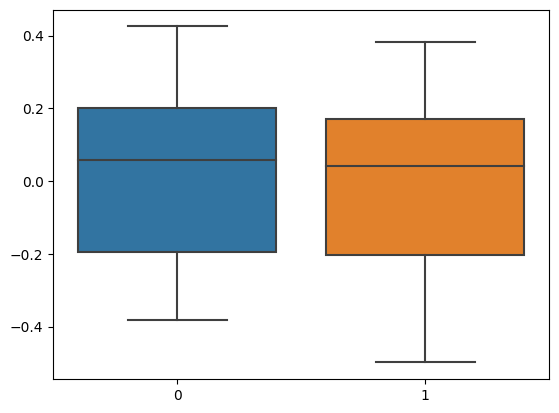

In [88]:
sns.boxplot(data=[gsvadf['Braun_data'].loc['module_0',projgrps['Braun_data'].loc['Response','Sample']],gsvadf['Braun_data'].loc['module_0',projgrps['Braun_data'].loc['No_Response','Sample']]])

In [35]:
for proj in projgrps.keys():
    if not randtestres[proj].loc['Response'][(randtestres[proj].loc['Response']['mean_difference'].abs()>=0.05) & (randtestres[proj].loc['Response']['p_value_adjusted']<=0.05)].empty:
        print(proj,randtestres[proj].loc['Response'][(randtestres[proj].loc['Response']['mean_difference'].abs()>=0.05) & (randtestres[proj].loc['Response']['p_value_adjusted']<=0.05)])

Mariathasan_data           u_statistic   p_value  mean_difference  p_value_adjusted
gene_set                                                          
rand_108    -3.734040  0.000188        -0.144366          0.028076
rand_134    -3.314341  0.000919        -0.095083          0.046202
rand_65     -3.295118  0.000984        -0.104709          0.046202
rand_92     -3.229440  0.001240        -0.076394          0.046202


In [36]:
for proj in projgrps.keys():
    if not testres[proj].loc['Response'][(testres[proj].loc['Response']['mean_difference'].abs()>=0.05) & (testres[proj].loc['Response']['p_value_adjusted']<=0.25)].empty:
        print(proj,testres[proj].loc['Response'][(testres[proj].loc['Response']['mean_difference'].abs()>=0.05) & (testres[proj].loc['Response']['p_value_adjusted']<=0.25)])

Nathanson_PRE_data             u_statistic   p_value  mean_difference  p_value_adjusted
gene_set                                                            
module_0      -2.449490  0.014306        -0.367151          0.126381
module_10     -1.714643  0.086411        -0.229361          0.135528
module_100    -1.959592  0.050044        -0.222903          0.126381
module_101    -2.449490  0.014306        -0.272444          0.126381
module_102    -1.469694  0.141645        -0.373748          0.181940
...                 ...       ...              ...               ...
module_83     -1.714643  0.086411        -0.367477          0.135528
module_86     -2.204541  0.027486        -0.483315          0.126381
module_87     -1.714643  0.086411        -0.344642          0.135528
module_88     -1.469694  0.141645        -0.239145          0.181940
module_99     -1.469694  0.141645        -0.208015          0.181940

[116 rows x 4 columns]
Mariathasan_data             u_statistic   p_value  mean_dif

In [146]:
sigicbs={}
for proj in projgrps.keys():
    if not testres[proj].loc['Response'][(testres[proj].loc['Response']['mean_difference'].abs()>=0.05) & (testres[proj].loc['Response']['p_value_adjusted']<=0.25)].empty:
        sigicbs[proj]=testres[proj].loc['Response'][(testres[proj].loc['Response']['mean_difference'].abs()>=0.05) & (testres[proj].loc['Response']['p_value_adjusted']<=0.25)]

In [148]:
meansigicbs={}
for proj in sigicbs.keys():
    meansigicbs[proj]=sigicbs[proj]['mean_difference']

In [149]:
meansigicbdf=pd.concat(meansigicbs,axis=1).dropna(how='all').dropna(how='all',axis=1)

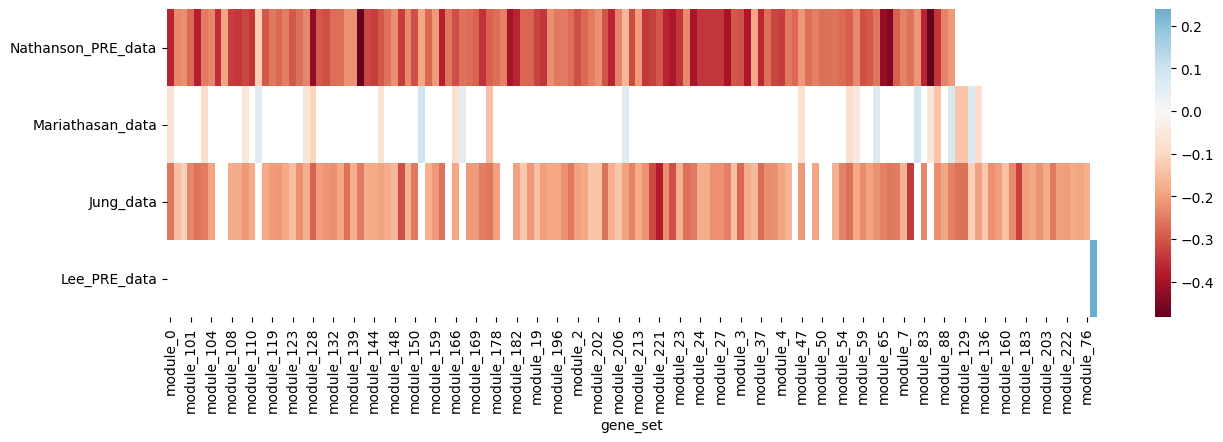

In [178]:
plt.rcParams["figure.figsize"] = (15,4)
g=sns.heatmap(meansigicbdf.transpose(),cmap='RdBu',center=0)
g.figure.savefig(figpath+"mods_icbsig_sfig4.svg",dpi=300,bbox_inches = "tight")

In [151]:
topconstidemods=['module_3','module_116','module_120','module_167','module_182','module_221','module_230']

In [152]:
iefmods=['module_0',
 'module_66',
 'module_111',
 'module_128',
 'module_129',
 'module_174',
 'module_182',
 'module_232',
 'module_55',
 'module_69',
 'module_87',
 'module_142',
 'module_145',
 'module_166',
 'module_222']

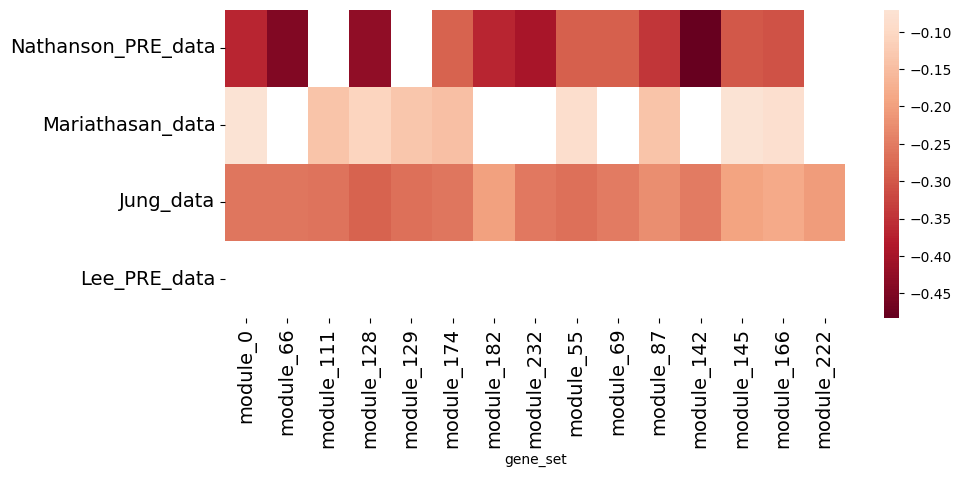

In [177]:
plt.rcParams["figure.figsize"] = (10,4)
g=sns.heatmap(meansigicbdf.transpose()[iefmods],cmap='RdBu',center=0)
g.tick_params(labelsize=14)
g.figure.savefig(figpath+"iefmods_icbsig_fig4.svg",dpi=300,bbox_inches = "tight")

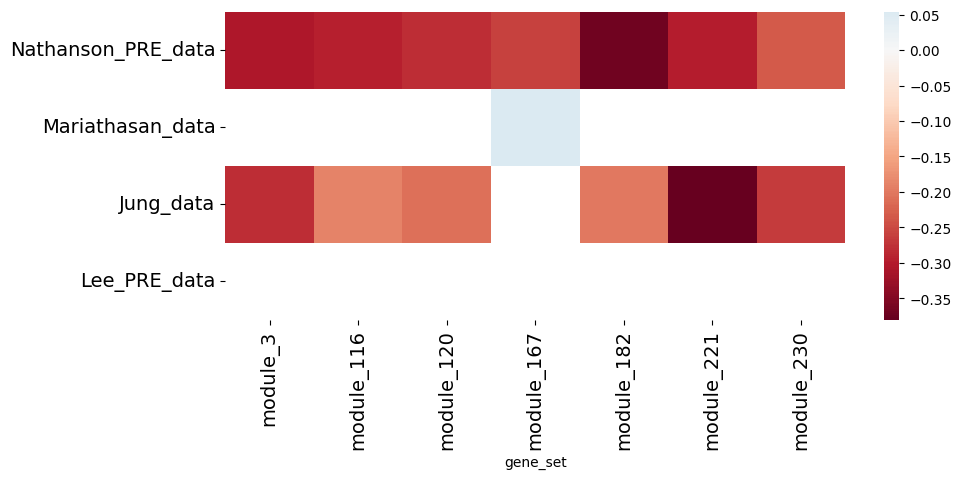

In [176]:
plt.rcParams["figure.figsize"] = (10,4)
g=sns.heatmap(meansigicbdf.transpose()[topconstidemods],cmap='RdBu',center=0)
g.set_xticklabels(g.get_xticklabels(),rotation=90)
g.tick_params(labelsize=14)
g.figure.savefig(figpath+"tideconsmod_icbsig_fig4.svg",dpi=300,bbox_inches = "tight")

In [34]:
gsvares=gp.gsva(data=tpmdf['Gide_PRE_data'].add(1).transform(np.log2),gene_sets=moddict,outdir=None)

In [35]:
gsvadf=gsvares.res2d.pivot(index='Term', columns='Name', values='ES')
gsvadf.index.name='Module'
gsvadf.columns.name='Samples'

In [36]:
gsvadf.head()

Samples,PD1_10_PRE,PD1_11_PRE,PD1_12_PRE,PD1_13_PRE,PD1_14_PRE,PD1_15_PRE,PD1_16_PRE,PD1_17_PRE,PD1_18_PRE,PD1_19_PRE,...,ipiPD1_37_PRE,ipiPD1_44_PRE,ipiPD1_45_PRE,ipiPD1_46_PRE,ipiPD1_47_PRE,ipiPD1_49_PRE,ipiPD1_50_PRE,ipiPD1_6_PRE,ipiPD1_7_PRE,ipiPD1_8_PRE
Module,,,,,,,,,,,,,,,,,,,,,
module_0,-0.314354,0.226009,0.195341,-0.173399,0.011242,0.16381,0.396938,0.315517,0.183177,-0.203926,...,-0.329788,0.332539,0.36076,0.255672,-0.309277,0.109706,0.18272,0.215194,-0.274452,-0.247963
module_10,0.001113,-0.314853,0.082443,-0.007443,0.012313,0.041623,0.152715,-0.182033,0.037439,0.108701,...,-0.060585,-0.205832,0.005303,-0.233975,-0.181124,-0.124643,0.261418,-0.066599,-0.198559,0.088362
module_100,-0.044418,-0.260866,0.112608,-0.014094,-0.018748,0.00111,0.142447,-0.107461,0.173732,0.055878,...,0.001316,-0.08159,0.032568,-0.177398,-0.135172,-0.051713,0.291627,0.039161,-0.182085,0.135785
module_101,0.013173,-0.092698,0.171282,-0.086624,-0.005045,0.135833,0.265194,0.097905,0.072375,0.156926,...,-0.0293,-0.27298,0.056335,0.157916,-0.186671,-0.074477,0.164927,-0.0019,-0.387894,0.036128
module_102,0.013657,-0.072864,0.236696,-0.107805,-0.024819,0.192873,0.065867,0.161413,0.233102,-0.058501,...,-0.173063,0.019328,0.055115,-0.056608,-0.321229,0.01022,0.364014,0.014407,-0.378414,0.044349


In [140]:
clindf['Gide_PRE_data'].columns

Index(['Sample', 'Patient.no.', 'Best.RECIST.response', 'RNA.Sequencing',
       'Resp_NoResp', 'Progression.Free.Survival..Days.',
       'Overall.Survival..Days.', 'Progressed.x', 'Last.Followup.Status',
       'PREEDT', 'Treatment.x', 'Patient no.', 'Age (Years)', 'Sex',
       'Treatment.y', 'Best RECIST response',
       'Progression Free Survival (Days)', 'Overall Survival (Days)',
       'Site of PRE Biopsy', 'Days to EDT Biopsy', 'Site of EDT Biopsy',
       'Progressed.y', 'Last Followup Status', 'RNA Sequencing',
       'Immunofluorescence Panel 1', 'Immunofluorescence Panel 2'],
      dtype='object')